<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Import torch
import torch

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# Setup random seed
RANDOM_SEED = 42

cpu


## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors. 
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.


Printing Data Frame
         X1        X2  y
0 -0.009332  0.390981  1
1  0.954574 -0.473756  1
2  0.918526 -0.425196  1
3  0.412768 -0.376385  1
4 -0.845320  0.528799  0
5  0.579542 -0.352979  1
6  0.294884 -0.209238  1
7 -0.014488  0.435896  1
8  1.626510 -0.281207  1
9  0.671598  0.786422  0

Printing Matplotlib
torch.float32


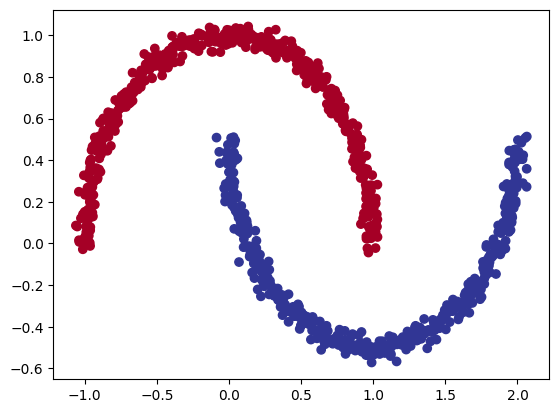

In [4]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt


X, y = make_moons(n_samples=1000, noise=0.03, random_state=RANDOM_SEED)

moons = pd.DataFrame({"X1":X[:, 0], "X2": X[:, 1], "y":y})
print("\nPrinting Data Frame")
print(moons.head(10))

print("\nPrinting Matplotlib")
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu)

# Converting from numpy to torch
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_SEED)

X_train = torch.from_numpy(X_train).to(device=device, dtype=torch.float32)
X_test = torch.from_numpy(X_test).to(device=device, dtype=torch.float32)
y_train = torch.from_numpy(y_train).to(device=device, dtype=torch.float32)
y_test = torch.from_numpy(y_test).to(device=device, dtype=torch.float32)

print(X_test.dtype)




## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [5]:
from torch import nn

class MoonModelV0(nn.Module):
  
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=10)    
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        
        self.tanh = nn.Tanh()

    def forward(self, x):
        # return self.layer2(self.relu(self.layer1(x)))

        l1 = self.layer1(x)
        r1 = self.tanh(l1)
        l2 = self.layer2(r1)
        r2 = self.tanh(l2)
        l3 = self.layer3(r2)    

        return l3
    
model0 = MoonModelV0().to(device)
print(model0.state_dict)

<bound method Module.state_dict of MoonModelV0(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (tanh): Tanh()
)>


## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [6]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model0.parameters(), lr=0.01)

print(loss_fn, optimizer)

BCEWithLogitsLoss() Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [7]:
# What's coming out of our model?
untrained_preds = model0(X_test)


# logits (raw outputs of model)
print("Logits:")
y_logits = model0(X_test)
print(f"The untrained preds are f{y_logits[:15]} and size is {y_logits.squeeze().shape}")
## Your code here ##

# Prediction probabilities
print("\nPred probs:")
y_pred_probs = torch.sigmoid(y_logits)
print(f"The pred probs are f{y_pred_probs[:15]}")
## Your code here ##

# Prediction labels
print("\nPred labels:")
y_preds = torch.round(y_pred_probs)
print(f"The pred labels are f{y_preds[:15]}")
## Your code here ##

Logits:
The untrained preds are ftensor([[-0.3860],
        [-0.4221],
        [-0.3407],
        [-0.4369],
        [-0.3186],
        [-0.3171],
        [-0.3853],
        [-0.3742],
        [-0.3428],
        [-0.4229],
        [-0.4402],
        [-0.3899],
        [-0.3801],
        [-0.3330],
        [-0.4697]], grad_fn=<SliceBackward0>) and size is torch.Size([200])

Pred probs:
The pred probs are ftensor([[0.4047],
        [0.3960],
        [0.4156],
        [0.3925],
        [0.4210],
        [0.4214],
        [0.4049],
        [0.4075],
        [0.4151],
        [0.3958],
        [0.3917],
        [0.4037],
        [0.4061],
        [0.4175],
        [0.3847]], grad_fn=<SliceBackward0>)

Pred labels:
The pred labels are ftensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<SliceBackward0>)


In [8]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

# TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
acc_fn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.4 MB/s eta 0:00:00a 0:00:01


MulticlassAccuracy()

In [9]:
## TODO: Uncomment this to set the seed
torch.manual_seed(RANDOM_SEED)
# Setup epochs
epochs = 1000

for epoch in range(epochs):

  model0.train()

  y_logits = model0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate the loss and accuracy

  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model0.eval()
  with torch.inference_mode():
    #1 . Forward pass

    test_logits = model0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(y_test, test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.5f}")

    

Epoch: 0 | Loss: 0.69449 | Acc: 0.50000
Epoch: 10 | Loss: 0.55048 | Acc: 0.72250
Epoch: 20 | Loss: 0.43900 | Acc: 0.77875
Epoch: 30 | Loss: 0.35156 | Acc: 0.82250
Epoch: 40 | Loss: 0.27978 | Acc: 0.87500
Epoch: 50 | Loss: 0.25292 | Acc: 0.89125
Epoch: 60 | Loss: 0.24234 | Acc: 0.89500
Epoch: 70 | Loss: 0.22859 | Acc: 0.90250
Epoch: 80 | Loss: 0.20740 | Acc: 0.91125
Epoch: 90 | Loss: 0.17850 | Acc: 0.92875
Epoch: 100 | Loss: 0.14080 | Acc: 0.94000
Epoch: 110 | Loss: 0.10131 | Acc: 0.96250
Epoch: 120 | Loss: 0.06711 | Acc: 0.98625
Epoch: 130 | Loss: 0.04278 | Acc: 0.99625
Epoch: 140 | Loss: 0.02748 | Acc: 1.00000
Epoch: 150 | Loss: 0.01838 | Acc: 1.00000
Epoch: 160 | Loss: 0.01301 | Acc: 1.00000
Epoch: 170 | Loss: 0.00971 | Acc: 1.00000
Epoch: 180 | Loss: 0.00758 | Acc: 1.00000
Epoch: 190 | Loss: 0.00613 | Acc: 1.00000
Epoch: 200 | Loss: 0.00509 | Acc: 1.00000
Epoch: 210 | Loss: 0.00432 | Acc: 1.00000
Epoch: 220 | Loss: 0.00373 | Acc: 1.00000
Epoch: 230 | Loss: 0.00326 | Acc: 1.00000
Epo

## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [ ]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

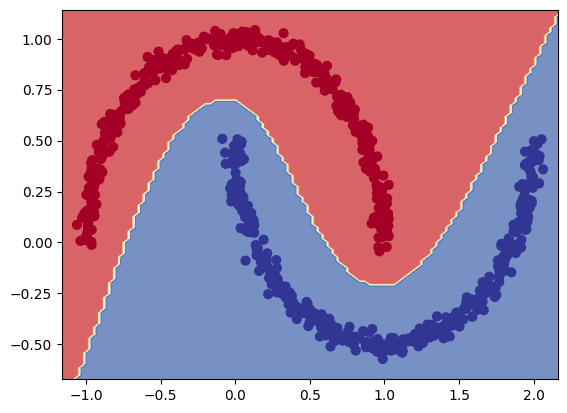

In [11]:
# Plot decision boundaries for training and test sets
plot_decision_boundary(model0, X_train, y_train)

## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

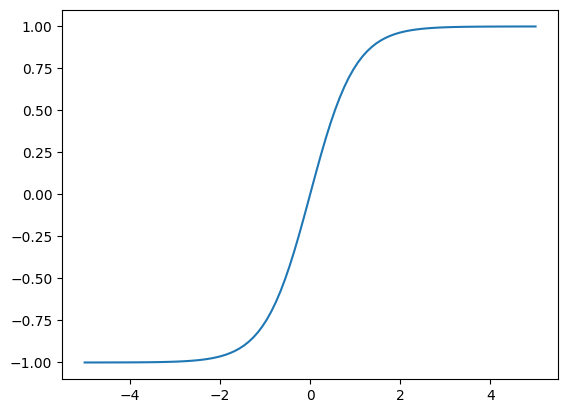

In [12]:
# Create a straight line tensor
x = torch.linspace(-5, 5, 100)

# Test torch.tanh() on the tensor and plot it
y_torch = torch.tanh(x)
plt.plot(x, y_torch)

/tmp/ipykernel_2668/1234312935.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))


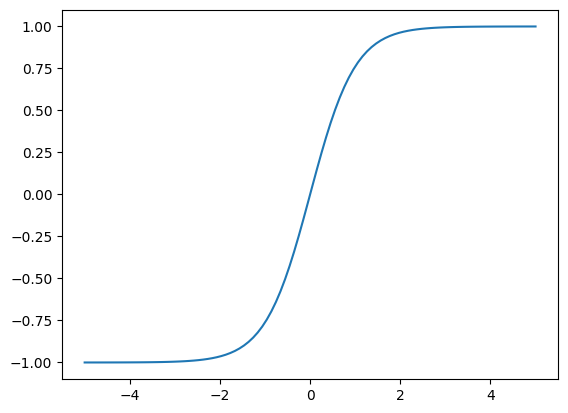

In [13]:
# Replicate torch.tanh() and plot it

def tanh(x):
  return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

y_custom_tanh = tanh(x)

plt.plot(x, y_custom_tanh)

## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

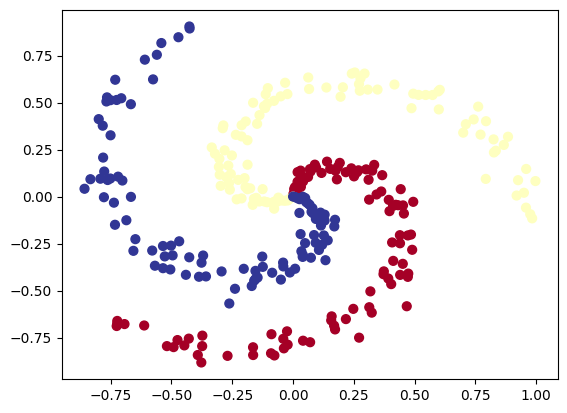

In [14]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [15]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long
# Create train and test splits
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_SEED)
print(X_train[:5], y_train[:5])  

# 2 in features
# 2 out features

print(X_train.device)


tensor([[ 0.0396, -0.3208],
        [ 0.3179, -0.5041],
        [ 0.0321,  0.0514],
        [ 0.8259,  0.2347],
        [ 0.4942,  0.5472]]) tensor([2, 0, 0, 1, 1])
cpu


In [16]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

# TODO: uncomment the two lines below to send the accuracy function to the device
acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
acc_fn

MulticlassAccuracy()

In [17]:
from torch import nn
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print(X_train.device)
# Create model by subclassing nn.Module

class SpiralModel0(nn.Module):

  def __init__(self):
    super().__init__()

    self.spiral_stack = nn.Sequential(
      nn.Linear(in_features=2, out_features=20),
      nn.Tanh(),
      nn.Linear(in_features=20, out_features=20),
      nn.Tanh(),
      nn.Linear(in_features=20, out_features=3),
    ) 

  def forward(self, x):
    return self.spiral_stack(x)

# Instantiate model and send it to device

spiralModel0 = SpiralModel0().to(device)
print(spiralModel0.state_dict())


cpu
cpu
OrderedDict({'spiral_stack.0.weight': tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802],
        [-0.3258, -0.0829],
        [-0.2872,  0.4691],
        [-0.5582, -0.3260],
        [-0.1997, -0.4252],
        [ 0.0667, -0.6984],
        [ 0.6386, -0.6007],
        [ 0.5459,  0.1177],
        [-0.2296,  0.4370],
        [ 0.1102,  0.5713],
        [ 0.0773, -0.2230]]), 'spiral_stack.0.bias': tensor([ 0.1900, -0.1918,  0.2976,  0.6313,  0.4087, -0.3091,  0.4082,  0.1265,
         0.3591, -0.4310, -0.7000, -0.2732, -0.5424,  0.5802,  0.2037,  0.2929,
         0.2236, -0.0123,  0.5534, -0.5024]), 'spiral_stack.2.weight': tensor([[ 0.0141, -0.1526,  0.0689, -0.0770,  0.0685, -0.0466,  0.1855, -0.1325,
         -0.1334, -0.1334,  0.2011,  0.0745,  0.2152, -0.

In [18]:
# Setup data to be device agnostic
print(X_train.device)
# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
y_logits = spiralModel0(X_train)
print(f"\nThe logit values are f{y_logits[:5]}")
## Your code here ##

print("Pred probs:")
y_pred_prob = torch.softmax(y_logits, dim=1)
print(f"The y_pred_prob is f{y_pred_prob[:5]}")  
## Your code here ##

print("Pred labels:")
y_pred_label = torch.argmax(y_pred_prob, dim=1)
print(f"The pred label is f{y_pred_label[:5]}")
## Your code here ##

cpu
Logits:

The logit values are ftensor([[-0.1974,  0.1858,  0.0024],
        [-0.2209,  0.2576, -0.0055],
        [-0.2170,  0.1890, -0.0225],
        [-0.3141,  0.3778, -0.1033],
        [-0.3034,  0.3003, -0.0957]], grad_fn=<SliceBackward0>)
Pred probs:
The y_pred_prob is ftensor([[0.2711, 0.3978, 0.3311],
        [0.2595, 0.4187, 0.3218],
        [0.2691, 0.4039, 0.3269],
        [0.2363, 0.4720, 0.2917],
        [0.2463, 0.4505, 0.3032]], grad_fn=<SliceBackward0>)
Pred labels:
The pred label is ftensor([1, 1, 1, 1, 1])


In [19]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(params=spiralModel0.parameters(), lr=0.01)

In [20]:
# Build a training loop for the model

EPOCHS = 1000
# Loop over data
for epoch in range(EPOCHS):

  ## Training
  spiralModel0.train()

  # 1. Forward pass
  y_logits = spiralModel0(X_train)
  y_pred_prob = torch.softmax(y_logits, dim=1)
  y_pred_labels = torch.argmax(y_pred_prob, dim=1)

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_train, y_pred_labels)
  
  # 3. Optimizer zero grad
  optimizer.zero_grad()
  

  # 4. Loss backward
  loss.backward()
  

  # 5. Optimizer step
  optimizer.step()
  

  ## Testing
  spiralModel0.eval()
  with torch.inference_mode():

    # 1. Forward pass
    test_logits = spiralModel0(X_test)
    test_pred_prob = torch.softmax(test_logits, dim=1)
    test_pred_labels = torch.argmax(test_pred_prob, dim=1)

    # 2. Caculate loss and acc

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(y_test, test_pred_labels)
    
  # Print out what's happening every 100 epochs
  
  if epoch % 100 == 0:
    print(f"For Epoch {epoch} the loss is {loss:.5f} and the acc is {acc:.5f}")
  

For Epoch 0 the loss is 1.08723 and the acc is 0.49167
For Epoch 100 the loss is 0.16155 and the acc is 0.96250
For Epoch 200 the loss is 0.04650 and the acc is 0.99167
For Epoch 300 the loss is 0.03071 and the acc is 0.99167
For Epoch 400 the loss is 0.02387 and the acc is 0.99167
For Epoch 500 the loss is 0.02030 and the acc is 0.99167
For Epoch 600 the loss is 0.01826 and the acc is 0.99167
For Epoch 700 the loss is 0.01704 and the acc is 0.99167
For Epoch 800 the loss is 0.01625 and the acc is 0.99167
For Epoch 900 the loss is 0.01566 and the acc is 0.99167


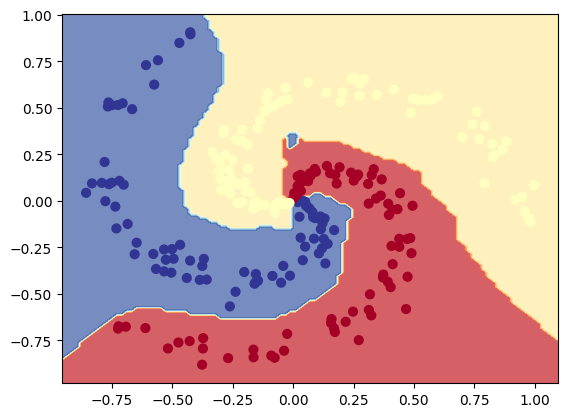

In [21]:
# Plot decision boundaries for training and test sets
plot_decision_boundary(spiralModel0, X_train, y_train)